In [85]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## Cutting Net - MLP

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

In [86]:
N_data = 250
data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity.npz", allow_pickle=True)

input_data = data["X"]
output_data = data["Y"].squeeze() # Remove all dimensions of size 1
x, t_domain = data["x"], data["t"]

print("X shape:", input_data.shape)
print("discontinuity shape:", output_data.shape)
print("discontinuity points:", output_data[0, 0])

X shape: (250, 1000)
discontinuity shape: (250, 1000)
discontinuity points: -0.37137137137137133


#### Step 2: Training

In [87]:
N, Nx = input_data.shape
Nt = t_domain.shape[0]

# train/val split
rng = np.random.default_rng(42)
all_idx = np.arange(N)
rng.shuffle(all_idx)
n_train = int(0.9 * N) # 90% for training, 10% for validation

train_idx = all_idx[:n_train]
val_idx = all_idx[n_train:]

# Convert data to tensors
X_train = torch.tensor(input_data[train_idx], dtype=torch.float32)
Y_train = torch.tensor(output_data[train_idx], dtype=torch.float32)
X_val = torch.tensor(input_data[val_idx], dtype=torch.float32)
Y_val = torch.tensor(output_data[val_idx], dtype=torch.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define MLP
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[40, 40, 40]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

model = MLP(input_data.shape[1], output_data.shape[1]).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00045, weight_decay=1e-6)

# Training loop
epochs = 2000
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    train_pred = model(X_train.to(device))
    loss = loss_fn(train_pred, Y_train.to(device))
    
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Validation step
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val.to(device))
        val_loss = loss_fn(val_pred, Y_val.to(device))
        val_losses.append(val_loss.item())

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/cutting_net_checkpoint.pt")
print("Saved: cutting_net_checkpoint.pt")

Epoch 100/2000, Loss: 0.012501, Val Loss: 0.012217
Epoch 200/2000, Loss: 0.004116, Val Loss: 0.004064
Epoch 300/2000, Loss: 0.001174, Val Loss: 0.001637
Epoch 400/2000, Loss: 0.000474, Val Loss: 0.000627
Epoch 500/2000, Loss: 0.000282, Val Loss: 0.000473
Epoch 600/2000, Loss: 0.000210, Val Loss: 0.000318
Epoch 700/2000, Loss: 0.000248, Val Loss: 0.000267
Epoch 800/2000, Loss: 0.000125, Val Loss: 0.000191
Epoch 900/2000, Loss: 0.000108, Val Loss: 0.000176
Epoch 1000/2000, Loss: 0.000086, Val Loss: 0.000149
Epoch 1100/2000, Loss: 0.000084, Val Loss: 0.000122
Epoch 1200/2000, Loss: 0.000115, Val Loss: 0.000144
Epoch 1300/2000, Loss: 0.000054, Val Loss: 0.000096
Epoch 1400/2000, Loss: 0.000059, Val Loss: 0.000098
Epoch 1500/2000, Loss: 0.000042, Val Loss: 0.000079
Epoch 1600/2000, Loss: 0.000037, Val Loss: 0.000071
Epoch 1700/2000, Loss: 0.000045, Val Loss: 0.000078
Epoch 1800/2000, Loss: 0.000040, Val Loss: 0.000070
Epoch 1900/2000, Loss: 0.000031, Val Loss: 0.000061
Epoch 2000/2000, Loss

#### Step 3: Test performance & Tracking

In [88]:
def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    X_test = torch.tensor(input_data_test, dtype=torch.float32)
    Y_test = torch.tensor(output_data_test, dtype=torch.float32)

    with torch.no_grad():
        test_pred = model(X_test.to(device)).cpu()

        test_mse = torch.mean((test_pred - Y_test) ** 2).item()
        test_mse_std = torch.std((test_pred - Y_test) ** 2).item()

        test_mse_percent = (test_mse / torch.mean(Y_test ** 2).item()) * 100
        test_mse_percent_std = (test_mse_std / torch.mean(Y_test ** 2).item()) * 100

    print(f"MSE: {test_mse:.6f} ± {test_mse_std:.6f}")
    print(f"MSE as percentage: {test_mse_percent:.2f}% ± {test_mse_percent_std:.2f}%")

    # Visualize one prediction
    i = 7
    pred_full = test_pred[i].numpy().reshape(output_data.shape[1:])
    true_full = Y_test[i].numpy().reshape(output_data.shape[1:])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

    axes[0].plot(x, input_data[i], label="u_0")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("u_0")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].scatter(t_domain, true_full, label='Ground Truth', s=2)
    axes[1].scatter(t_domain, pred_full, label='Prediction', s=2, alpha=0.3)
    axes[1].set_title("Discontinuity Location Prediction")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("x location")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Training")
    axes[2].plot(val_losses, label="Validation")
    axes[2].set_yscale('log')
    axes[2].set_title("Loss Tracking")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].grid(True)
    axes[2].legend()

In [89]:
N_data = 20
data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity_test.npz", allow_pickle=True)

input_data_test = data["X"]
output_data_test = data["Y"].squeeze() # Remove all dimensions of size 1
x_test, t_domain_test = data["x"], data["t"]

Total parameters: 84,320, trainable parameters: 84,320
MSE: 0.000045 ± 0.000084
MSE as percentage: 0.03% ± 0.06%


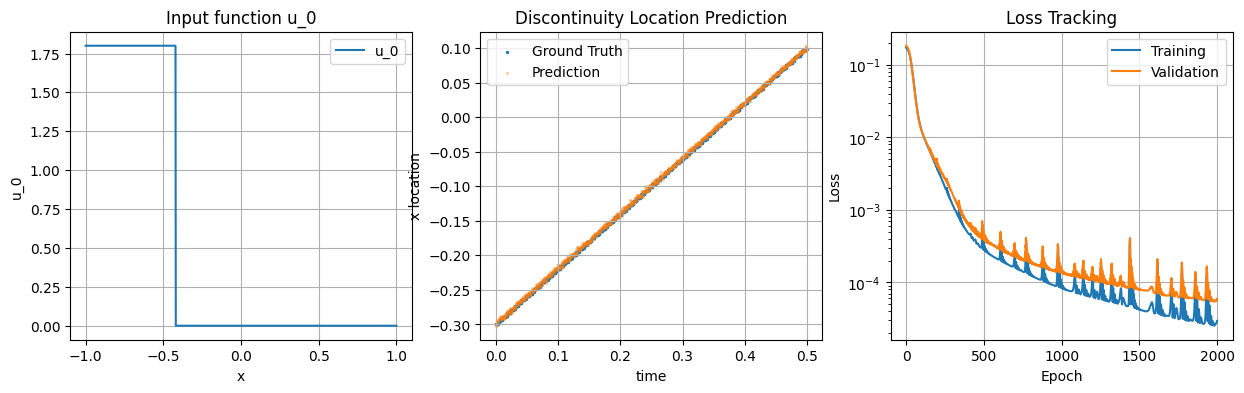

In [90]:
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")

show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test)